# Network Intrusion Detection with KNN
This notebook builds and evaluates a K-Nearest Neighbors model to classify network traffic as normal or intrusion.

In [1]:
import pandas as pd

# Load the dataset from the project folder
df = pd.read_csv("network_intrusion_dataset.csv")

# Preview
df.head()

,Port_Number,Received_Packets,Received_Bytes,Sent_Bytes,Sent_Packets,Port_Alive_Duration_Sec,Packets_Rx_Dropped,Packets_Tx_Dropped,Packets_Rx_Errors,Packets_Tx_Errors,...,Unknown_Load(Latest),Latest_Bytes_Counter,Is_Valid,Table_ID,Active_Flow_Entries,Packets_Looked_Up,Packets_Matched,Max_Size,Traffic_Type,Intrusion_Traffic_Type
0,4,305111,25506841,100234870,284579,1657,0,0,0,0,...,0,0,1,0,6,992868,992744,-1,Normal,Normal
1,2,209,20671,6316631,274,96,0,0,0,0,...,6303353,183877,1,0,8,90551,90494,-1,Intrusion,PortScan
2,4,150,19774,6475473,3054,166,0,0,0,0,...,6439888,502,1,0,6,7516,7418,-1,Intrusion,TCP-SYN
3,1,4699,100986365,124574097,413351,2267,0,0,0,0,...,0,0,1,0,8,664849,664714,-1,Normal,Normal
4,3,990,104058,88896,778,792,0,0,0,0,...,7152,715,1,0,5,4328,4201,-1,Intrusion,Blackhole


In [2]:
list(df.columns)

['Port_Number',
 'Received_Packets',
 'Received_Bytes',
 'Sent_Bytes',
 'Sent_Packets',
 'Port_Alive_Duration_Sec',
 'Packets_Rx_Dropped',
 'Packets_Tx_Dropped',
 'Packets_Rx_Errors',
 'Packets_Tx_Errors',
 'Delta_Received_Packets',
 'Delta_Received_Bytes',
 'Delta_Sent_Bytes',
 'Delta_Sent_Packets',
 'Delta_Port_Alive_Duration_Sec',
 'Delta_Packets_Rx_Dropped',
 'Delta_Packets_Tx_Dropped',
 'Delta_Packets_Rx_Errors',
 'Delta_Packets_Tx_Errors',
 'Connection_Point',
 'Total_Load(Rate)',
 'Total_Load(Latest)',
 'Unknown_Load(Rate)',
 'Unknown_Load(Latest)',
 'Latest_Bytes_Counter',
 'Is_Valid',
 'Table_ID',
 'Active_Flow_Entries',
 'Packets_Looked_Up',
 'Packets_Matched',
 'Max_Size',
 'Traffic_Type',
 'Intrusion_Traffic_Type']

### Data overview
Check columns, shape, and basic statistics to understand the dataset.

In [3]:
#check the number of rows and columns in the dataset
df.shape

(4998, 33)

In [4]:
import plotly.express as px

# Bar chart for Traffic_Type (Normal vs Intrusion)
Traffic_Type_fig = px.bar(df, x='Traffic_Type', title="Traffic Types")

# Bar chart for Intrusion_Traffic_Type (specific attack types)
Intrusion_Traffic_Type_fig = px.bar(df, x='Intrusion_Traffic_Type', title="Attacks Types")

# Stacked bar chart: for each Traffic_Type, show the composition of Intrusion_Traffic_Type
Intrusion_Types_Per_Traffic_fig = px.bar(df, x='Traffic_Type', color='Intrusion_Traffic_Type',
                                         title="Attack Types In Intrusion Traffic",
                                         color_discrete_sequence=px.colors.qualitative.Vivid)

# Remove the outline of the bars (makes them look cleaner)
Traffic_Type_fig.update_traces(dict(marker_line_width=0))
Intrusion_Traffic_Type_fig.update_traces(dict(marker_line_width=0))
Intrusion_Types_Per_Traffic_fig.update_traces(dict(marker_line_width=0))

# Show all three plots
Traffic_Type_fig.show()
Intrusion_Traffic_Type_fig.show()
Intrusion_Types_Per_Traffic_fig.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Port_Number                    4998 non-null   int64 
 1   Received_Packets               4998 non-null   int64 
 2   Received_Bytes                 4998 non-null   int64 
 3   Sent_Bytes                     4998 non-null   int64 
 4   Sent_Packets                   4998 non-null   int64 
 5   Port_Alive_Duration_Sec        4998 non-null   int64 
 6   Packets_Rx_Dropped             4998 non-null   int64 
 7   Packets_Tx_Dropped             4998 non-null   int64 
 8   Packets_Rx_Errors              4998 non-null   int64 
 9   Packets_Tx_Errors              4998 non-null   int64 
 10  Delta_Received_Packets         4998 non-null   int64 
 11  Delta_Received_Bytes           4998 non-null   int64 
 12  Delta_Sent_Bytes               4998 non-null   int64 
 13  Del

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Port_Number,4998.0,2.235094e+00,1.062464e+00,1.0,1.00,2.0,3.00,4.0
Received_Packets,4998.0,8.393248e+04,1.223941e+05,10.0,836.50,3595.5,178957.75,352772.0
Received_Bytes,4998.0,4.721429e+07,4.951127e+07,856.0,8643970.00,25593619.0,75727934.00,271591638.0
Sent_Bytes,4998.0,4.743702e+07,4.894604e+07,5775.0,6548716.25,29771955.0,76097629.00,239242994.0
Sent_Packets,4998.0,1.484074e+05,1.497138e+05,42.0,1042.25,134206.5,287707.50,421598.0
Port_Alive_Duration_Sec,4998.0,1.377490e+03,9.844243e+02,26.0,241.00,1385.0,2237.00,3317.0
Packets_Rx_Dropped,4998.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.00,0.0
Packets_Tx_Dropped,4998.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.00,0.0
Packets_Rx_Errors,4998.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.00,0.0
Packets_Tx_Errors,4998.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.00,0.0


In [7]:
df = df.drop(columns=df.loc[:, 'Packets_Rx_Dropped':'Packets_Tx_Errors'].columns)
df = df.drop(columns=df.loc[:, 'Delta_Packets_Rx_Dropped':'Delta_Packets_Tx_Errors'].columns)
df = df.drop(['Is_Valid', 'Table_ID', 'Max_Size'], axis=1)
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Port_Number,4998.0,NaN,NaN,NaN,2.235094,1.062464,1.0,1.0,2.0,3.0,4.0
Received_Packets,4998.0,NaN,NaN,NaN,83932.478191,122394.118041,10.0,836.5,3595.5,178957.75,352772.0
Received_Bytes,4998.0,NaN,NaN,NaN,47214291.872549,49511274.8009,856.0,8643970.0,25593619.0,75727934.0,271591638.0
Sent_Bytes,4998.0,NaN,NaN,NaN,47437016.121048,48946041.43338,5775.0,6548716.25,29771955.0,76097629.0,239242994.0
Sent_Packets,4998.0,NaN,NaN,NaN,148407.440176,149713.797741,42.0,1042.25,134206.5,287707.5,421598.0
Port_Alive_Duration_Sec,4998.0,NaN,NaN,NaN,1377.489996,984.42426,26.0,241.0,1385.0,2237.0,3317.0
Delta_Received_Packets,4998.0,NaN,NaN,NaN,104.55042,784.471254,0.0,0.0,4.0,4.0,15659.0
Delta_Received_Bytes,4998.0,NaN,NaN,NaN,333088.118848,1180140.157127,0.0,0.0,556.0,560.0,6302708.0
Delta_Sent_Bytes,4998.0,NaN,NaN,NaN,311865.495798,1154417.431288,278.0,280.0,556.0,560.0,6303182.0
Delta_Sent_Packets,4998.0,NaN,NaN,NaN,95.544818,765.859992,2.0,2.0,4.0,4.0,15592.0


### Feature cleanup and preparation
Drop low-value columns, inspect missing values, and export the prepared dataset.

In [8]:
df.isna().sum()/len(df)*100

Port_Number                      0.0
Received_Packets                 0.0
Received_Bytes                   0.0
Sent_Bytes                       0.0
Sent_Packets                     0.0
Port_Alive_Duration_Sec          0.0
Delta_Received_Packets           0.0
Delta_Received_Bytes             0.0
Delta_Sent_Bytes                 0.0
Delta_Sent_Packets               0.0
Delta_Port_Alive_Duration_Sec    0.0
Connection_Point                 0.0
Total_Load(Rate)                 0.0
Total_Load(Latest)               0.0
Unknown_Load(Rate)               0.0
Unknown_Load(Latest)             0.0
Latest_Bytes_Counter             0.0
Active_Flow_Entries              0.0
Packets_Looked_Up                0.0
Packets_Matched                  0.0
Traffic_Type                     0.0
Intrusion_Traffic_Type           0.0
dtype: float64

In [9]:
df.to_csv("prepared_network_intrusion_dataset.csv", index=False)

### Modeling setup
Load the prepared dataset, split features/target, and create train/test sets.

In [10]:
df_prepared = pd.read_csv("prepared_network_intrusion_dataset.csv")

In [11]:
# Separate model features and target labels
feature_matrix = df_prepared.drop(columns=['Traffic_Type', 'Intrusion_Traffic_Type'])
target_labels = df_prepared['Traffic_Type']

# Check selected input variables
list(feature_matrix.columns)

['Port_Number',
 'Received_Packets',
 'Received_Bytes',
 'Sent_Bytes',
 'Sent_Packets',
 'Port_Alive_Duration_Sec',
 'Delta_Received_Packets',
 'Delta_Received_Bytes',
 'Delta_Sent_Bytes',
 'Delta_Sent_Packets',
 'Delta_Port_Alive_Duration_Sec',
 'Connection_Point',
 'Total_Load(Rate)',
 'Total_Load(Latest)',
 'Unknown_Load(Rate)',
 'Unknown_Load(Latest)',
 'Latest_Bytes_Counter',
 'Active_Flow_Entries',
 'Packets_Looked_Up',
 'Packets_Matched']

In [12]:
# Preview target labels
target_labels.head()

0       Normal
1    Intrusion
2    Intrusion
3       Normal
4    Intrusion
Name: Traffic_Type, dtype: object

In [13]:
from sklearn.model_selection import train_test_split

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, target_labels, test_size=0.2, random_state=14, stratify=target_labels
)

print('X_train Instances', X_train.shape)
print('X_test Instances', X_test.shape)

X_train Instances (3998, 20)
X_test Instances (1000, 20)


### Train and evaluate baseline model
Train a baseline KNN model, inspect predictions, and evaluate with multiple metrics.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

# Baseline KNN model
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
# Perform predictions on the test data
y_pred = knn_model.predict(X_test)

# Compare actual vs predicted values
comparison_knn_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_knn_df.to_csv("knn_pred_comparison.csv", index=True)

# Show only the first rows for a clean output
comparison_knn_df.head()

,Actual,Predicted
2409,Normal,Normal
2612,Normal,Normal
4016,Intrusion,Intrusion
79,Intrusion,Intrusion
456,Normal,Normal


In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Intrusion       0.88      0.82      0.85       472
      Normal       0.85      0.90      0.87       528

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



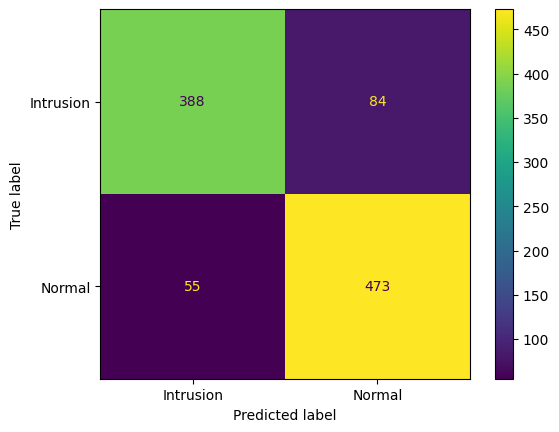

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn = confusion_matrix(y_test, y_pred, labels=knn_model.classes_)
disp_knn_cm = ConfusionMatrixDisplay(cm_knn, display_labels=knn_model.classes_)
disp_knn_cm.plot()

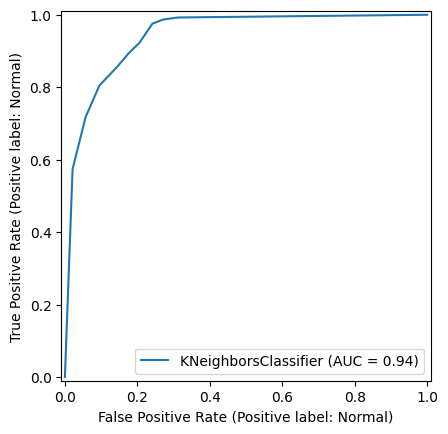

In [18]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(knn_model, X_test, y_test)

Text(0, 0.5, 'Mean Error')

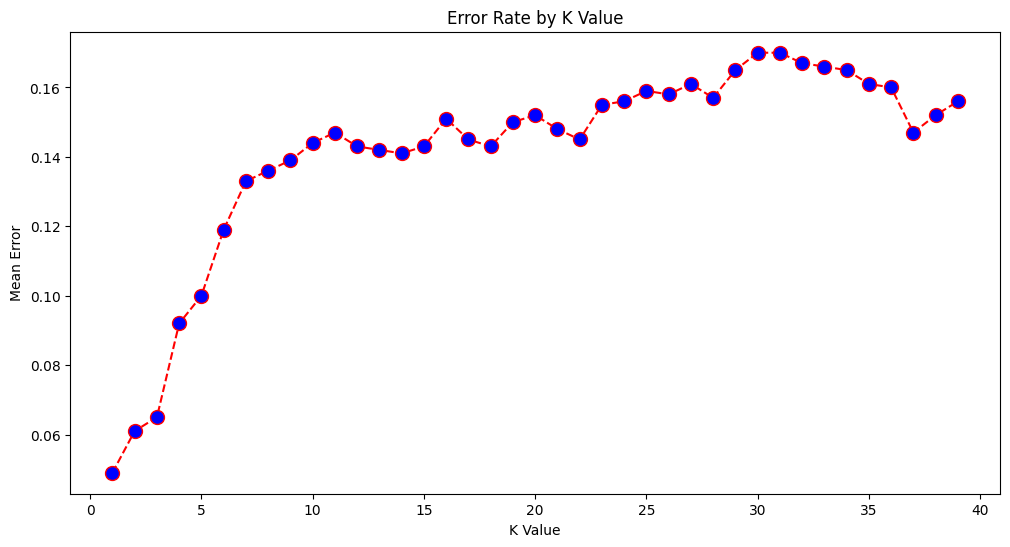

In [19]:
# Calculate error for K values between 1 and 39
error = []
import numpy as np
import matplotlib.pyplot as plt

for i in range(1, 40):
    knn_candidate = KNeighborsClassifier(n_neighbors=i)
    knn_candidate.fit(X_train, y_train)
    pred_i = knn_candidate.predict(X_test)
    error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate by K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

### Tune K value manually
Plot error vs K to understand sensitivity to neighborhood size.

In [20]:
from sklearn.neighbors import KNeighborsClassifier

# Alternative KNN with k=1
knn_k1_model = KNeighborsClassifier(n_neighbors=1)
knn_k1_model.fit(X_train, y_train)

y_pred = knn_k1_model.predict(X_test)

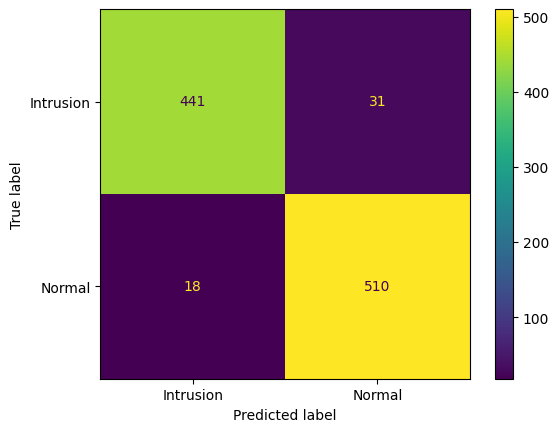

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn1 = confusion_matrix(y_test, y_pred, labels=knn_k1_model.classes_)
disp_knn1_cm = ConfusionMatrixDisplay(cm_knn1, display_labels=knn_k1_model.classes_)
disp_knn1_cm.plot()

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Intrusion       0.96      0.93      0.95       472
      Normal       0.94      0.97      0.95       528

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



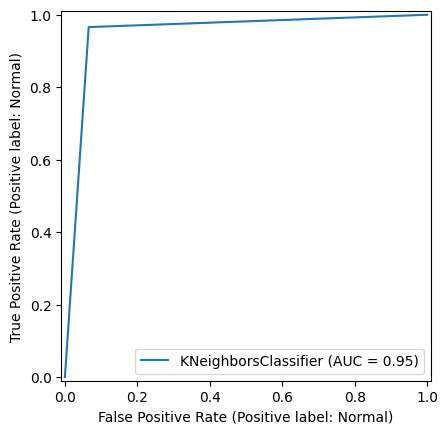

In [23]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(knn_k1_model, X_test, y_test)

In [24]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Grid-search over K and distance metric
knn_search_model = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 25), 'metric': ['euclidean', 'manhattan']}

knn_gscv = GridSearchCV(knn_search_model, param_grid, cv=5, scoring='roc_auc')
knn_gscv.fit(feature_matrix, target_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 1, 2..., 22, 23, 24])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [25]:
# Check top performing n_neighbors’ value
knn_gscv.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(4)}

              precision    recall  f1-score   support

   Intrusion       0.98      0.98      0.98       472
      Normal       0.98      0.98      0.98       528

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



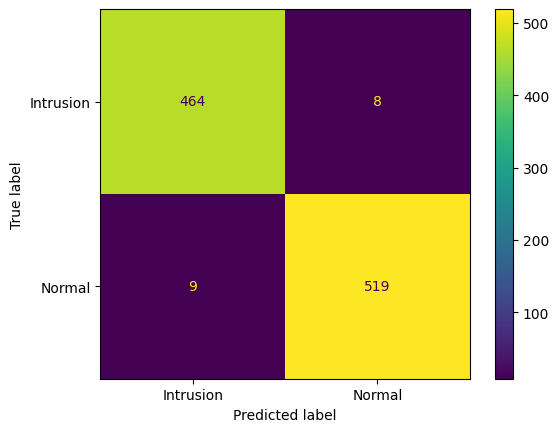

In [26]:
# Evaluate best grid-search model on test data
y_pred = knn_gscv.predict(X_test)

cm_knn_gscv = confusion_matrix(y_test, y_pred, labels=knn_gscv.classes_)
disp_knn_gscv_cm = ConfusionMatrixDisplay(cm_knn_gscv, display_labels=knn_gscv.classes_)
disp_knn_gscv_cm.plot()

print(classification_report(y_test, y_pred))

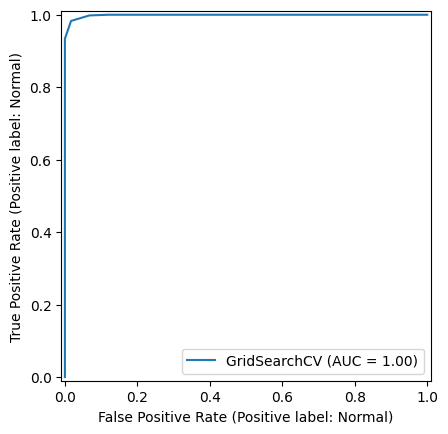

In [27]:
from sklearn.metrics import RocCurveDisplay
knn_gscv_roc = RocCurveDisplay.from_estimator(knn_gscv, X_test, y_test)